# ICL experiment analysis

Cross-run view over `runs/*` produced by `ExperimentTracker`. Best-so-far curves, success
rates, the experiment index, and per-run drill-down.

Run from the `src/` directory with the analysis extra installed:
`pip install -e ".[analysis]"`. Set `RUNS_DIR` below to your runs folder.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from results.analysis import load_index, load_progress, load_solutions, plot_best_so_far, plot_success_rate

RUNS_DIR = "../runs"   # change to an absolute path if running the notebook elsewhere

## Experiment index
One row per run: problem, knobs, best result, status.

In [8]:
idx = load_index(RUNS_DIR)
idx = idx.iloc[5]
idx

run                 toy_best_n4_g6x4_20260721_224254
problem                                          toy
strategy                                        best
n_context                                          4
group_size                                         6
groups_per_batch                                   4
num_generations                                   30
generations_done                                  30
best_score                                       4.0
status                                      complete
updated_at                       2026-07-21T22:44:23
Name: 5, dtype: object

## Best-so-far by generation
One line per run. Minimize problems (erdos, ac1) trend **down** (lower native metric is better).

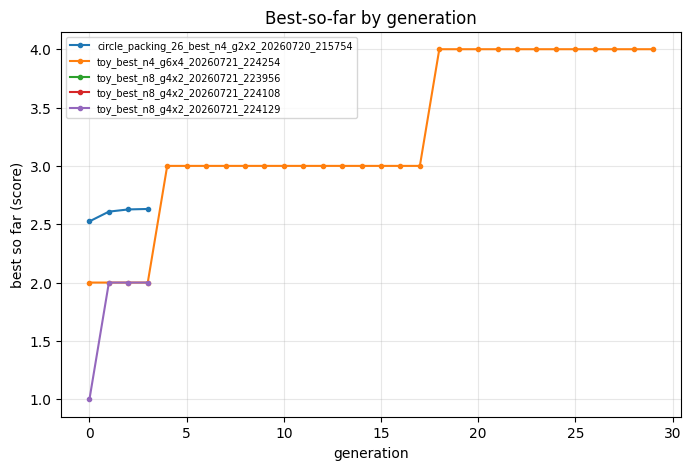

In [9]:
plot_best_so_far(RUNS_DIR)
plt.show()

## Success rate by generation
Fraction of the group_size candidates that were valid, per generation.

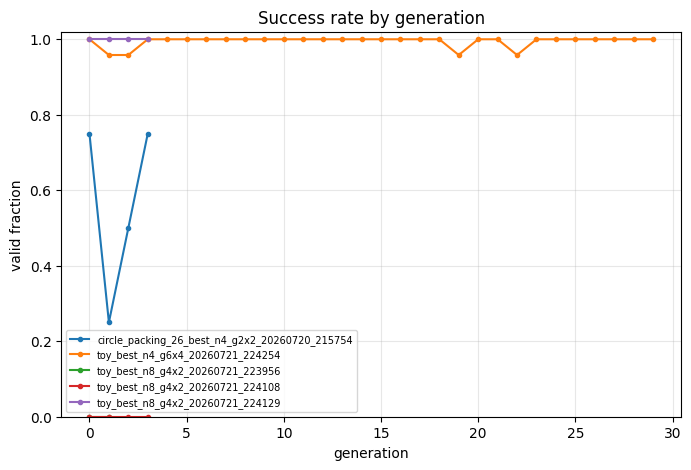

In [10]:
plot_success_rate(RUNS_DIR)
plt.show()

## Per-run drill-down
Pick a run from the index above; inspect its per-generation table and top solutions.

In [16]:
run = idx["run"].iloc[0] if len(idx) else None
print("run:", run)
prog = load_progress(RUNS_DIR, runs=[run]) if run else None
prog

run: circle_packing_26_best_n4_g3x1_20260720_195632


,generation,n_valid,n_failed,success_rate,gen_best,best_so_far,buffer_size,puct_T,run
0,0,3,0,1.0,2.630439,2.630439,3,3,circle_packing_26_best_n4_g3x1_20260720_195632


In [17]:
sols = load_solutions(RUNS_DIR, run) if run else None
# top-10 solutions by raw_score; the .py files live in runs/<run>/solutions/<sol>.py
sols.sort_values("raw_score", ascending=False).head(10) if sols is not None and len(sols) else sols

,sol,state_id,gen,parent_sol,parent_state_id,raw_score,value,correctness,entrypoint
2,sol_000003,e1e0fe90-f6d5-431d-92c5-02b5f5c715b6,0,seed,56b9595d-3457-4f58-8455-116b371c8d46,2.630439,2.630439,1.0,run_packing
1,sol_000002,ab7b6943-c1bd-4bf4-93b5-62cf29b1e9de,0,seed,56b9595d-3457-4f58-8455-116b371c8d46,2.340000,2.340000,1.0,run_packing
0,sol_000001,899b0a0b-3ac7-4d47-ae03-e676dba5af76,0,seed,56b9595d-3457-4f58-8455-116b371c8d46,1.466109,1.466109,1.0,run_packing
